# **Line Charts**


In this lab, you will focus on using line charts to analyze trends over time and across different categories in a dataset.



## Objectives


In this lab you will perform the following:


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
!pip install pandas


In [2]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



#### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv


--2026-03-16 22:59:11--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  97.1MB/s    in 1.6s    

2026-03-16 22:59:13 (97.1 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



#### Step 2: Import necessary libraries and load the dataset


In [5]:
import pandas as pd
import matplotlib.pyplot as plt


#### Load the data


In [6]:
df = pd.read_csv("survey-data.csv")


#### Display the first few rows to understand the structure of the data


In [7]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


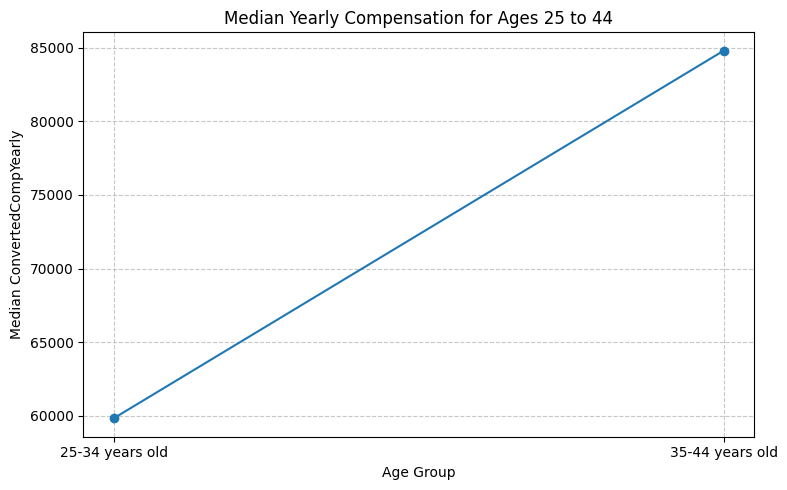

In [14]:
# Define the age groups of interest
target_age_groups = ['25-34 years old', '35-44 years old']

# Filter the DataFrame for the specified age groups and non-null compensation
df_filtered = df[df['Age'].isin(target_age_groups)].dropna(subset=['ConvertedCompYearly', 'Age'])

# Group by Age and calculate the median of ConvertedCompYearly
# Use observed=True to only group by categories present in the filtered data,
# avoiding potential issues with non-existent categories from a global categorical dtype.
median_comp_25_45 = df_filtered.groupby('Age', observed=True)['ConvertedCompYearly'].median().reset_index()

# Explicitly drop any rows where 'Age' might still be NaN (float) if they somehow appeared
# This ensures that all 'Age' values are valid strings before attempting to set as Categorical for plotting.
median_comp_25_45.dropna(subset=['Age'], inplace=True)

# Ensure the age groups are in the correct order for plotting
# Convert 'Age' to string type first, to avoid any potential type issues with pd.Categorical
median_comp_25_45['Age'] = median_comp_25_45['Age'].astype(str)
median_comp_25_45['Age'] = pd.Categorical(median_comp_25_45['Age'], categories=target_age_groups, ordered=True)
median_comp_25_45 = median_comp_25_45.sort_values('Age')

# Create the line chart
plt.figure(figsize=(8, 5))
plt.plot(median_comp_25_45['Age'], median_comp_25_45['ConvertedCompYearly'], marker='o', linestyle='-')
plt.title('Median Yearly Compensation for Ages 25 to 44')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 1: Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


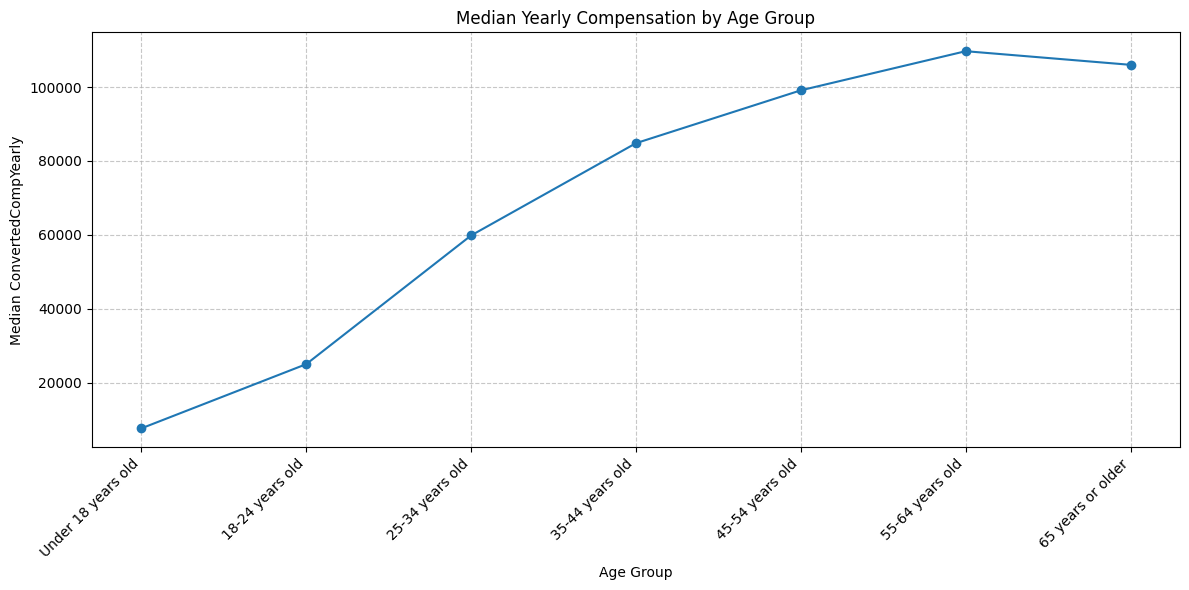

In [13]:
import matplotlib.pyplot as plt

# Define a custom order for the 'Age' categories
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Convert 'Age' column to a categorical type with the specified order
df['Age'] = pd.Categorical(df['Age'], categories=age_order, ordered=True)

# Filter out NaN values in 'ConvertedCompYearly' and 'Age' before grouping
# Use observed=True to only consider categories actually present in the filtered data
median_comp_by_age = df.dropna(subset=['ConvertedCompYearly', 'Age']).groupby('Age', observed=True)['ConvertedCompYearly'].median().reset_index()

# Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(median_comp_by_age['Age'], median_comp_by_age['ConvertedCompYearly'], marker='o', linestyle='-')
plt.title('Median Yearly Compensation by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


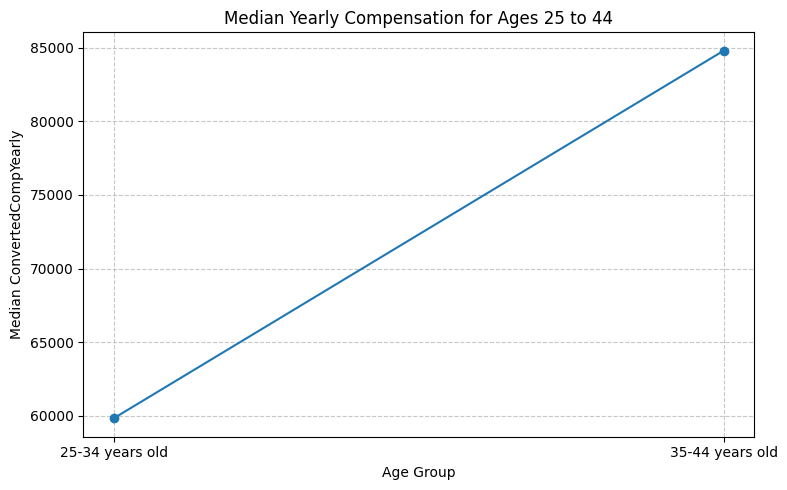

In [18]:
# Define the age groups of interest
target_age_groups = ['25-34 years old', '35-44 years old']

# Filter the DataFrame for the specified age groups and non-null compensation
df_filtered = df[df['Age'].isin(target_age_groups)].dropna(subset=['ConvertedCompYearly', 'Age'])

# Group by Age and calculate the median of ConvertedCompYearly
# Use observed=True to only group by categories present in the filtered data,
# avoiding potential issues with non-existent categories from a global categorical dtype.
median_comp_25_45 = df_filtered.groupby('Age', observed=True)['ConvertedCompYearly'].median().reset_index()

# Explicitly drop any rows where 'Age' might still be NaN (float) if they somehow appeared
# This ensures that all 'Age' values are valid strings before attempting to set as Categorical for plotting.
median_comp_25_45.dropna(subset=['Age'], inplace=True)

# Ensure the age groups are in the correct order for plotting
# Convert 'Age' to string type first, to avoid any potential type issues with pd.Categorical
median_comp_25_45['Age'] = median_comp_25_45['Age'].astype(str)
median_comp_25_45['Age'] = pd.Categorical(median_comp_25_45['Age'], categories=target_age_groups, ordered=True)
median_comp_25_45 = median_comp_25_45.sort_values('Age')

# Create the line chart
plt.figure(figsize=(8, 5))
plt.plot(median_comp_25_45['Age'], median_comp_25_45['ConvertedCompYearly'], marker='o', linestyle='-')
plt.title('Median Yearly Compensation for Ages 25 to 44')
plt.xlabel('Age Group')
plt.ylabel('Median ConvertedCompYearly')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 2: Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


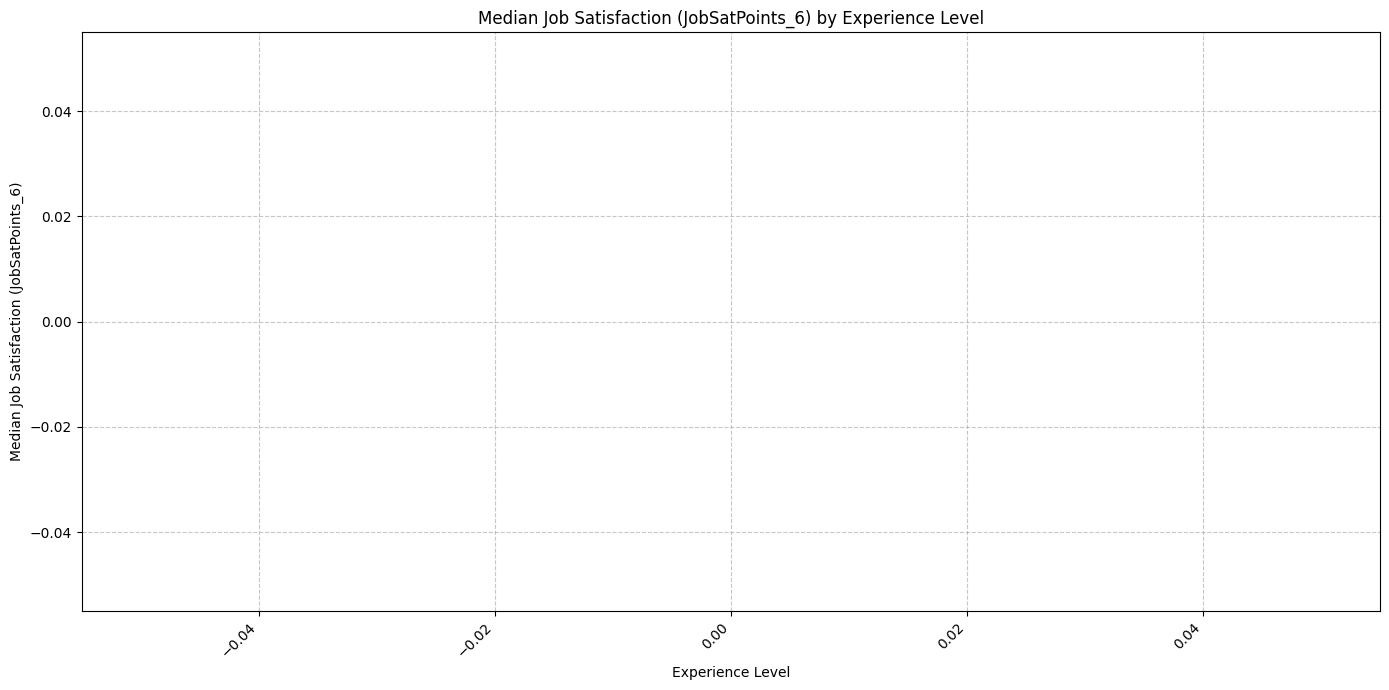

In [15]:
# Define a custom order for 'WorkExp' categories
workexp_order = [
    'Less than 1 year',
    '1 to 4 years',
    '5 to 9 years',
    '10 to 14 years',
    '15 to 19 years',
    '20 to 24 years',
    '25 to 29 years',
    '30 to 34 years',
    '35 to 39 years',
    '40 to 44 years',
    '45 to 49 years',
    '50 or more years'
]

# Convert 'WorkExp' column to a categorical type with the specified order
df['WorkExp'] = pd.Categorical(df['WorkExp'], categories=workexp_order, ordered=True)

# Filter out NaN values in 'JobSatPoints_6' and 'WorkExp' before grouping
# Use observed=True to only consider categories actually present in the filtered data
median_jobsat_by_workexp = df.dropna(subset=['JobSatPoints_6', 'WorkExp']).groupby('WorkExp', observed=True)['JobSatPoints_6'].median().reset_index()

# Create the line chart
plt.figure(figsize=(14, 7))
plt.plot(median_jobsat_by_workexp['WorkExp'], median_jobsat_by_workexp['JobSatPoints_6'], marker='o', linestyle='-')
plt.title('Median Job Satisfaction (JobSatPoints_6) by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Median Job Satisfaction (JobSatPoints_6)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 3: Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


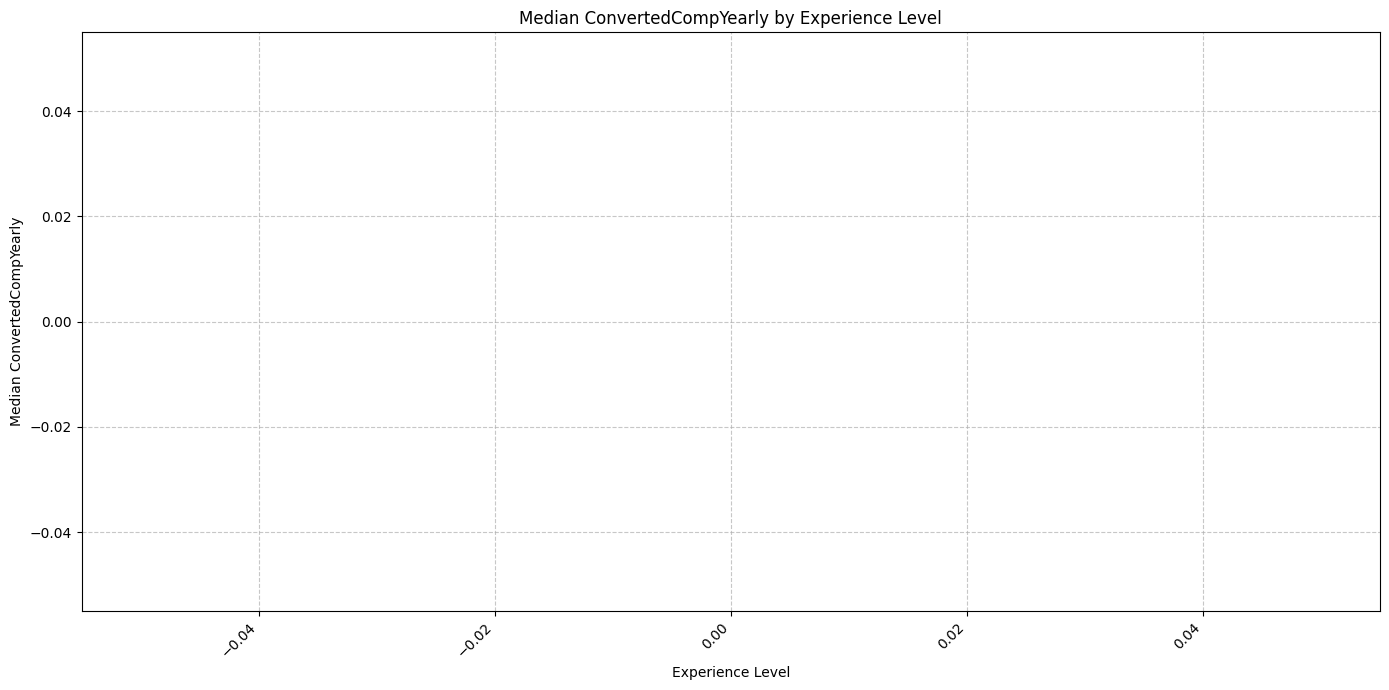

In [16]:
# Filter out NaN values in 'ConvertedCompYearly' and 'WorkExp' before grouping
# Use observed=True to only consider categories actually present in the filtered data
median_comp_by_workexp = df.dropna(subset=['ConvertedCompYearly', 'WorkExp']).groupby('WorkExp', observed=True)['ConvertedCompYearly'].median().reset_index()

# Create the line chart
plt.figure(figsize=(14, 7))
plt.plot(median_comp_by_workexp['WorkExp'], median_comp_by_workexp['ConvertedCompYearly'], marker='o', linestyle='-')
plt.title('Median ConvertedCompYearly by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Median ConvertedCompYearly')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


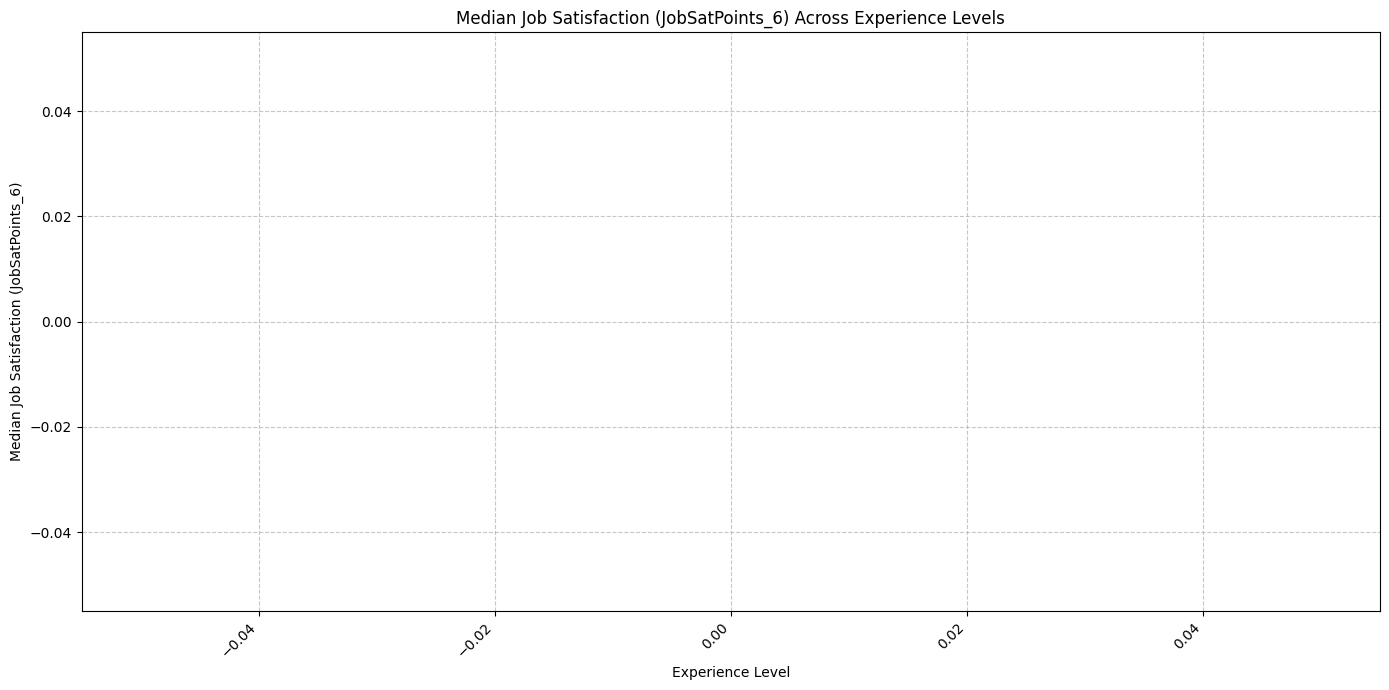

In [17]:
# This task is identical to Task 2.1, so we reuse the code.

# Filter out NaN values in 'JobSatPoints_6' and 'WorkExp' before grouping
# Use observed=True to only consider categories actually present in the filtered data
median_jobsat_by_workexp_2 = df.dropna(subset=['JobSatPoints_6', 'WorkExp']).groupby('WorkExp', observed=True)['JobSatPoints_6'].median().reset_index()

# Create the line chart
plt.figure(figsize=(14, 7))
plt.plot(median_jobsat_by_workexp_2['WorkExp'], median_jobsat_by_workexp_2['JobSatPoints_6'], marker='o', linestyle='-')
plt.title('Median Job Satisfaction (JobSatPoints_6) Across Experience Levels')
plt.xlabel('Experience Level')
plt.ylabel('Median Job Satisfaction (JobSatPoints_6)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Final Step: Review


In this lab, you focused on analyzing trends in compensation and job satisfaction, specifically exploring how these metrics change with age and experience levels using line charts.


### Summary


In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.


## Authors:
Sumant chakravarty
